### **Transfer Learning:-**

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import PIL
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import  Sequential


### **Load flower dataset: -**

In [68]:
data_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos',origin = data_url ,cache_dir='.',untar = True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

In [69]:
data_dir

'./datasets/flower_photos'

In [70]:
import pathlib
from pathlib import Path

data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('datasets/flower_photos')

In [71]:
print(data_dir.exists())  # Should be True
print(list(data_dir.glob('*')))
print(list(data_dir.glob('*//*.jpg')))

True
[PosixPath('datasets/flower_photos/flower_photos')]
[]


In [72]:
data_dir = Path("datasets/flower_photos/flower_photos")

In [73]:
list(data_dir.glob('*/*.jpg'))[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/16209331331_343c899d38.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5777669976_a205f61e5b.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/4860145119_b1c3cbaa4e_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15011625580_7974c44bce.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/17953368844_be3d18cf30_m.jpg')]

In [74]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [75]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/16209331331_343c899d38.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5777669976_a205f61e5b.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/4860145119_b1c3cbaa4e_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15011625580_7974c44bce.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/17953368844_be3d18cf30_m.jpg')]

In [76]:
roses[1]

PosixPath('datasets/flower_photos/flower_photos/roses/5777669976_a205f61e5b.jpg')

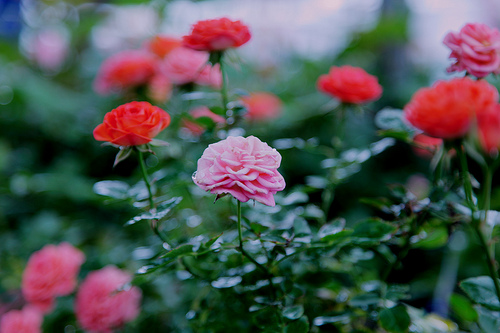

In [77]:
PIL.Image.open(str(roses[1]))

In [78]:
tulips = list(data_dir.glob('tulips/*'))
tulips[8]

PosixPath('datasets/flower_photos/flower_photos/tulips/5543457754_89c44c88de_n.jpg')

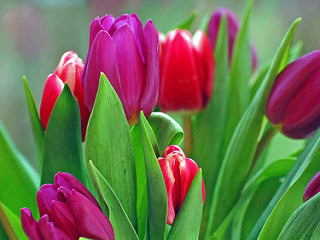

In [79]:
PIL.Image.open(str(tulips[104]))

In [80]:
flowers_image_dict = {
    'roses' : list(data_dir.glob('roses/*')),
    'daisy' : list(data_dir.glob('daisy/*')),
    'dandelion' : list(data_dir.glob('dandelion/*')),
    'sunflowers' : list(data_dir.glob('sunflowers/*')),
    'tulips' : list(data_dir.glob('tulips/*')),
}

In [81]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [82]:
flowers_image_dict['roses'][:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/16209331331_343c899d38.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5777669976_a205f61e5b.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/4860145119_b1c3cbaa4e_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/15011625580_7974c44bce.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/17953368844_be3d18cf30_m.jpg')]

In [83]:
str(flowers_image_dict['roses'][:5])

"[PosixPath('datasets/flower_photos/flower_photos/roses/16209331331_343c899d38.jpg'), PosixPath('datasets/flower_photos/flower_photos/roses/5777669976_a205f61e5b.jpg'), PosixPath('datasets/flower_photos/flower_photos/roses/4860145119_b1c3cbaa4e_n.jpg'), PosixPath('datasets/flower_photos/flower_photos/roses/15011625580_7974c44bce.jpg'), PosixPath('datasets/flower_photos/flower_photos/roses/17953368844_be3d18cf30_m.jpg')]"

### **Convert Image into matrix.**

In [84]:
img = cv2.imread(str(flowers_image_dict['roses'][9]))
img.shape

(334, 500, 3)

In [85]:
cv2.resize(img,(224,224)).shape

(224, 224, 3)

In [86]:
x = []
y = []
for flower_name ,images in flowers_image_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(224,224))
        x.append(resized_img)
        y.append(flowers_labels_dict[flower_name])


x = np.array(x)
y = np.array(y) 

In [87]:
x

array([[[[  6,   1,   1],
         [  0,   1,   1],
         [ 51,  36,  30],
         ...,
         [244, 245, 243],
         [244, 245, 243],
         [244, 245, 243]],

        [[  3,   8,  23],
         [  3,   2,   1],
         [ 14,   7,  18],
         ...,
         [243, 244, 242],
         [243, 244, 242],
         [243, 244, 242]],

        [[ 42,  88, 165],
         [  7,   1,   3],
         [ 12,  12,  24],
         ...,
         [244, 245, 243],
         [244, 245, 243],
         [244, 245, 243]],

        ...,

        [[144, 109,  87],
         [149, 114,  91],
         [147, 113,  89],
         ...,
         [152, 122,  95],
         [154, 124,  97],
         [150, 120,  92]],

        [[150, 115,  93],
         [151, 117,  94],
         [151, 117,  93],
         ...,
         [150, 121,  93],
         [153, 123,  96],
         [151, 121,  93]],

        [[153, 119,  96],
         [148, 114,  90],
         [150, 116,  92],
         ...,
         [151, 121,  94],
        

### **Spliting the data: -**

In [88]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train, y_test = train_test_split(x,y,random_state = 4)


### **Scaling data:**

In [89]:
X_train_scaled = x_train / 255
X_test_scaled = x_test / 255

### **Buid a Convolutional Neural Networks: -**

In [90]:
num_classes = 5

model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes,activation = 'softmax')
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=1) 

/Users/yuvrajbhatkariya/data/VScode.C++/Python/myenv/lib/python3.12/site-packages/keras/src/backend/tensorflow/nn.py:708: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 267ms/step - accuracy: 0.2997 - loss: 1.7917


In [91]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.5230 - loss: 1.1802


[1.1845365762710571, 0.5305010676383972]

### **Improving accuracy using agumentation: -**

In [92]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(180, 180, 3)),
    layers.RandomFlip("vertical", input_shape=(180, 180, 3)),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])


/Users/yuvrajbhatkariya/data/VScode.C++/Python/myenv/lib/python3.12/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


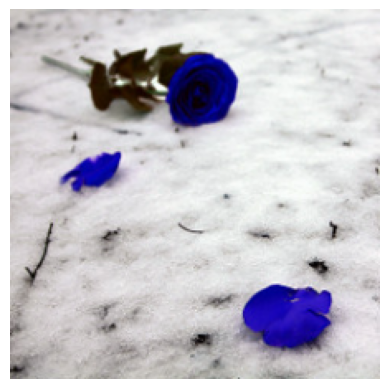

In [93]:
plt.axis('off')
plt.imshow(x[6])

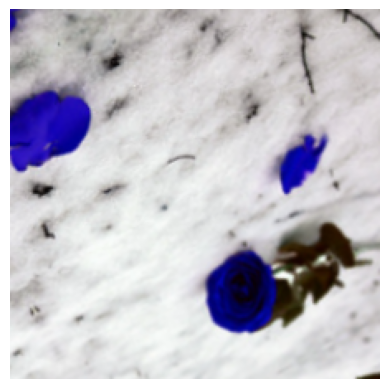

In [94]:
plt.axis('off')
plt.imshow(data_augmentation(x)[6].numpy().astype("uint8"))

In [95]:
num_classes = 5

model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.3),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(64, activation='relu'),
  layers.Dense(32, activation='relu'),
  # layers.Dropout(0.2),
  layers.Dense(num_classes,activation = 'softmax')
])
# model.summary()
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=1) 

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_13" is incompatible with the layer: expected axis -1 of input shape to have value 30976, but received input with shape (32, 50176)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 224, 224, 3), dtype=float32)
  • training=True
  • mask=None

In [ ]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.5808 - loss: 1.1222


[1.1271592378616333, 0.5653594732284546]

### **Apply pre Trained Model : -**

In [ ]:
X_train_scaled.shape


(2752, 180, 180, 3)

In [58]:
import tensorflow as tf
import tensorflow_hub as hub

num_of_flowers = 5

# Load the pre-trained model
pretrained_model_without_top_layer = hub.KerasLayer(
    "https://tfhub.dev/google/imagenet/mobilenet_v2_100_224/feature_vector/4",
    trainable=False
)

# Define a Sequential model
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(224, 224, 3)),  # Define input shape
    tf.keras.layers.Resizing(224, 224),                     # resize to match MobileNetV2
    tf.keras.layers.Lambda(lambda x: pretrained_model_without_top_layer(x)),  # Wrap the hub layer
    tf.keras.layers.Dense(num_of_flowers, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,405 (25.02 KB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
model.fit(X_train_scaled, y_train, epochs=5)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 18s 183ms/step - accuracy: 0.5354 - loss: 1.1547
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 179ms/step - accuracy: 0.8323 - loss: 0.4620
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 18s 214ms/step - accuracy: 0.8827 - loss: 0.3385
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 17s 192ms/step - accuracy: 0.9036 - loss: 0.3021
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 185ms/step - accuracy: 0.9285 - loss: 0.2410


In [60]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - accuracy: 0.8528 - loss: 0.4053


[0.3784191906452179, 0.8681917190551758]